In [1]:
import pandas as pd
import json
from flatten_json import flatten
#from tqdm import tqdm
from tqdm.auto import tqdm# serial iteration without driftdown between exceution
from multiprocessing import Pool
from parallelbar import progress_map#wrapper around multiprocessing, handles all the backend orchestration internally so you don't have to manage imap or loops manually
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor, as_completed
import re



In [2]:
from rapidfuzz import fuzz
import numpy as np

### (A) flattening of data and cleaning NAN values(common to both old and new data)

In [3]:
#!jupyter lab --version
#%pip install --upgrade jupyterlab

In [4]:
## Flattening the json and its dataframe generation

In [4]:
#!pip3 install datasets
#!pip3 install --upgrade --force-reinstall tqdm datasets
#!pip3 install --upgrade --force-reinstall tqdm
!pip3 install --upgrade tqdm

In [5]:
from tqdm import tqdm

In [6]:
from datasets import Dataset, load_dataset

In [7]:
def flat(egs):
    flat_json =flatten(egs, separator ="_")
    return(flat_json)

# This guard is required to prevent multiprocessing loops/crashes
if __name__ == "__main__":
    with open("ctg-studies.json", 'r', encoding ="utf-8") as file:
        data =json.load(file)

    total_len =len(data)
    

    with ThreadPoolExecutor(max_workers=20) as executor:
        result_generator = executor.map(flat, data)
        
        flatten_data = list(tqdm(result_generator, total =total_len, desc="Fetching_data"))
    
    
    '''
    with ProcessPoolExecutor(max_workers=20) as executor:
        result_generator = executor.map(flat, data)
        
        flatten_data = list(tqdm(result_generator, total =total_len, desc="Fetching_data"))
    '''

Fetching_data: 100%|██████████████████████████████████████████████████████████| 10000/10000 [00:00<00:00, 69633.26it/s]


In [8]:
from pprint import pprint

In [9]:
#pprint(flatten_data[0])

In [10]:
print(len(flatten_data))

10000


In [11]:
df_CT = pd.DataFrame(flatten_data)
df_CT = df_CT.drop(columns ="protocolSection_eligibilityModule")
#df_CT.dropna(inplace=True)===>#avoid using inplcae=True(1.it doesn't reduce memory,copy of org_df is made, 
#2.it prevents method chaining and frequently triggers Pandas' confusing SettingWithCopyWarning if the DataFrame is a slice of another dataset.)

df_CT =df_CT.dropna().reset_index(drop=True)#shouldn't be done if one needs to refer org_df, also assigned df in that case should be diff from org_df

In [12]:
df_CT.head()

,protocolSection_identificationModule_nctId,protocolSection_identificationModule_briefTitle,protocolSection_identificationModule_officialTitle,protocolSection_descriptionModule_briefSummary,protocolSection_eligibilityModule_eligibilityCriteria
0,NCT07759089,The Efficacy of Tranexamic Acid and Adrenaline...,A Comparison Between the Efficacy of Tranexami...,"During bronchoscopy (a procedure using a thin,...",Inclusion Criteria:\n\n* Adult patients of any...
1,NCT07759076,Evaluation of Automated Laser-Assisted Tattoo ...,Evaluation of Automated Laser-Assisted Tattoo ...,The goal of this study is to collect prelimina...,Inclusion criteria:\n\n* Adults (18 - 84 years...
2,NCT07759063,Clinical Validation of Self-Pacing Algorithms ...,Clinical Validation of Self-Pacing Algorithms ...,The goal of this clinical trial is to evaluate...,Inclusion Criteria:\n\n* Current client of Qua...
3,NCT07759050,Clinical Study of Spectral CT,"Prospective, Single-center, Randomized Clinica...",This study will prospective enroll 80 subjects...,Inclusion Criteria:\n\n* Age ≥ 18 years.\n* 18...
4,NCT07759037,Fluorescent Hand Hygiene Training and Long-Ter...,Durability of Fluorescent Hand Hygiene Trainin...,This single-group quasi-experimental study wil...,Inclusion Criteria:\n\n* First-year nursing st...


In [13]:
df_CT.shape

(9973, 5)

In [14]:
'''
df_positive_check =df_CT[df_CT['protocolSection_identificationModule_nctId'].isin(['NCT07698041', 'NCT07730580', 'NCT07629700', 
                                                                                   'NCT07743138', 'NCT07695428',  'NCT07707180', 
                                                                                   'NCT07718906', 'NCT07751757', 'NCT07658781',  
                                                                                   'NCT07663903'])]
#df_positive_check[::]
for block in df_positive_check["protocolSection_eligibilityModule_eligibilityCriteria"].to_list():
    print(block)
    print('-'*100)
'''

'\ndf_positive_check =df_CT[df_CT[\'protocolSection_identificationModule_nctId\'].isin([\'NCT07698041\', \'NCT07730580\', \'NCT07629700\', \n                                                                                   \'NCT07743138\', \'NCT07695428\',  \'NCT07707180\', \n                                                                                   \'NCT07718906\', \'NCT07751757\', \'NCT07658781\',  \n                                                                                   \'NCT07663903\'])]\n#df_positive_check[::]\nfor block in df_positive_check["protocolSection_eligibilityModule_eligibilityCriteria"].to_list():\n    print(block)\n    print(\'-\'*100)\n'

### (A1)diagnosis on df_CT(common part)

In [479]:
text ="""protocolSection_eligibilityModule_eligibilityCriteria': 'Inclusion Criteria:\n\n* Adult patients of any age and gender undergoing 
diagnostic flexible bronchoscopy for suspected benign or malignant airway disease\n* Required endobronchial forceps biopsy during the 
procedure\n* Developed moderate endobronchial bleeding following biopsy (defined as bleeding that obscured the bronchoscopic view, 
required repeated suctioning to clear the airway, and required endoscopic intervention for hemostasis, but remained hemodynamically stable)\n\n
Exclusion Criteria:\n\n* Severe bleeding (requiring instillation of ice-cold saline, bronchoscopic tamponade, electrocautery, or argon plasma 
coagulation)\n* Life-threatening bleeding (requiring endotracheal intubation, or spontaneous hemoptysis of more than 100-150 mL per hour)\n* 
Contraindications to bronchoscopy, including:\n\n  1. Cardiac arrhythmias\n  2. Oxygen saturation below 90% on supplemental oxygen\n  
3. Acute respiratory failure with hypercapnia\n  4. Tracheal obstruction\n* Bleeding diathesis with raised INR or platelet count less than 
50,000/mm³\n* Unstable coronary artery disease\n* Hypersensitivity to tranexamic acid or adrenaline"""

In [480]:
regex =r"[\\n\s]+(?='*(In|Ex)clusion[\\n\s]+Criteria)"
regex =r"[\\n\s]+((?='*Inclusion[\\n\s]+Criteria)|(?='*Exclusion[\\n\s]+Criteria))"
regex =r"[\\n\s]+(?='*Inclusion[\\n\s]+Criteria)|[\\n\s]+(?='*Exclusion[\\n\s]+Criteria)"
#print(re.split(r"[\\n|\s]+(?=('*Inclusion|'*Exclusion)[\\n|\s]+Criteria)", text))
#print("-"*80)
#print(re.split(r"[\\n|\s]+(?=('*In|'*Ex)clusion[\\n|\s]+Criteria)", text))
#print("-"*80)
ls_splt=re.split(regex, text)
print(ls_splt, len(ls_splt))


["protocolSection_eligibilityModule_eligibilityCriteria':", "'Inclusion Criteria:\n\n* Adult patients of any age and gender undergoing \ndiagnostic flexible bronchoscopy for suspected benign or malignant airway disease\n* Required endobronchial forceps biopsy during the \nprocedure\n* Developed moderate endobronchial bleeding following biopsy (defined as bleeding that obscured the bronchoscopic view, \nrequired repeated suctioning to clear the airway, and required endoscopic intervention for hemostasis, but remained hemodynamically stable)", 'Exclusion Criteria:\n\n* Severe bleeding (requiring instillation of ice-cold saline, bronchoscopic tamponade, electrocautery, or argon plasma \ncoagulation)\n* Life-threatening bleeding (requiring endotracheal intubation, or spontaneous hemoptysis of more than 100-150 mL per hour)\n* \nContraindications to bronchoscopy, including:\n\n  1. Cardiac arrhythmias\n  2. Oxygen saturation below 90% on supplemental oxygen\n  \n3. Acute respiratory failure

In [ ]:
'''
def preprocess(input_text):
    regex =r"[\\n\s]+(?='*Inclusion[\\n\s]+Criteria)|[\\n\s]+(?='*Exclusion[\\n\s]+Criteria)"
    Inc_ex_split =re.split(regex, input_text)[1:]
    
    Inc_ex_split
    return(Inc_ex_split)
    
'''    

### End of diagnosis

## (B) **split inclusion_exclusion**

#### 1. <u>**Data for original data(iter 1)**</u>

In [ ]:

#df_CT["Inclusion_criteria", "Exclusion_criteria"] = df_CT["protocolSection_eligibilityModule_eligibilityCriteria"].apply(preprocess)

pattern =r"[\\n\s]+(?='*Inclusion[\\n\s]+Criteria)|[\\n\s]+(?='*Exclusion[\\n\s]+Criteria)"
split_series = df_CT["protocolSection_eligibilityModule_eligibilityCriteria"].str.split(pattern, expand=True)

inc_ex_pattern = r"[\b]*(Ex|In)clusion[\\n\s]+Criteria[\b]*"
df_CT["Inclusion_Criteria"] =split_series[0].str.replace(inc_ex_pattern, lambda m: m.group(0).upper(), flags=re.IGNORECASE)
df_CT["Exclusion_Criteria"] = split_series[1].str.replace(inc_ex_pattern, lambda m: m.group(0).upper(), flags=re.IGNORECASE)


In [ ]:
split_series.shape

**Append the title(breif and official with conditions of similarity) with summary and inclusion_criteria to yeild postive_chunks(old data-iter1)**

In [ ]:
chunk1 = "The quick brown fox jumps over the lazy dog."
chunk2 = "The lazy fox was jumped over by quick fox"#semantically sam but literal arrangemnet different
chunk3 = "The quick brown fox jumps over the lazy dogs."#semantically bit diff but lietrally almost same

similarity_perc_1_2 = fuzz.ratio(chunk1, chunk2)
print(f"similarity_%_1_2:{similarity_perc_1_2}\n+{'#'*50}")
similarity_perc_1_3 = fuzz.ratio(chunk1, chunk3)
print(f"similarity_%_1_3:{similarity_perc_1_3}\n+{'#'*50}")

In [ ]:
#Vectorize fuzz so that it accepts series inputs(of columns)
vec_fuzz =np.vectorize(fuzz.ratio)

#conditions:-
conditions= [
    (vec_fuzz(df_CT["protocolSection_identificationModule_briefTitle"].str.lower(), 
              df_CT["protocolSection_identificationModule_officialTitle"].str.lower())>=80)
]

#choices(to avoid literally same official and brief title):-
choices = [
    "TITLE: "+ df_CT["protocolSection_identificationModule_officialTitle"]+ '\n'+ "SUMMARY: "+ df_CT["protocolSection_descriptionModule_briefSummary"]
    +'\n' +df_CT["Inclusion_Criteria"]
]

#combine both
df_CT["Positive_chunks"] = np.select(conditions, choices, default = "TITLE: "+ df_CT["protocolSection_identificationModule_briefTitle"] +" "+
                                     df_CT["protocolSection_identificationModule_officialTitle"]+ '\n'+ 
                                     "SUMMARY: "+ df_CT["protocolSection_descriptionModule_briefSummary"]
                                     +'\n' +df_CT["Inclusion_Criteria"])


In [ ]:
df_CT.head()

In [ ]:
'''
# Simple if-else condition checking rapidfuzz score inline
df['result'] = df.apply(
    lambda row: row['company_A'] if fuzz.ratio(row['company_A'], row['company_B']) >= 80 
    else row['company_A'] + " & " + row['company_B'], 
    axis=1
)
'''

#could have been used if records were less, .apply() causes massive overheads on large records

In [ ]:
df_CT.columns

In [ ]:
df_CT.drop(columns =['protocolSection_identificationModule_briefTitle',
       'protocolSection_identificationModule_officialTitle',
       'protocolSection_descriptionModule_briefSummary',
       'protocolSection_eligibilityModule_eligibilityCriteria',
       'Inclusion_Criteria', 'Exclusion_Criteria'], inplace=True)

df_CT.rename(columns={"protocolSection_identificationModule_nctId": "nctId"}, inplace=True)

#### 2. <u>**Data for new data(iter 2)**</u>

**diff fn trial to find perfect case(both return list of inclusion-exclusion blocks)**
- <u>extract_inc_exc_discrete</u>:- Handles eligibilityCriteria blocks where there are 2 2 separate sub-blocks(of inclusion and exclusion)
- <u>extract_inc_exc_generalized</u>:- Handles cases where inclusion-exlcusion sub-blocks appear in tandem(more than one sub-blocks for both)

In [15]:
def extract_inc_exc_discrete(text):
    if not isinstance(text, str):
        return "", ""
    
    inclusion_pattern, exclusion_pattern = r"(?i)\binclusion\W+\n*criteria\b[:\s\-]*", r"(?i)\bexclusion\W+\n*criteria\b[:\s\-]*"
    #find staring position of both inculsion and exclusion pattern
    inc_span = re.search(inclusion_pattern, text)
    exc_span = re.search(exclusion_pattern, text)
   # print(f"inclusion_span:-{inc_span}, exclusion_span:-{exc_span}")
    
    inc_str, exc_str="",""
    
    if(inc_span and exc_span):#both present
        if(inc_span.start() < exc_span.start()):#common case
            inc_str = text[inc_span.end(): exc_span.start()]
            exc_str = text[exc_span.end():]
        else:
            exc_str = text[exc_span.end():inc_span.start()]#rare case but happens
            inc_str = text[inc_span.end():]
    
    elif(inc_span):# only inclusion criteria present
        inc_str = text[inc_span.end():]
        
    elif(exc_span):# only exclusion criteria present
        exc_str = text[exc_span.end():]
    
    else:#where both spans absent, inclusion text defaulted to text
        inc_str = text
    
    return(inc_str, exc_str)

#inclusion_pattern, exclusion_pattern = r"(?i)[\b]*inclusion\W+\n*criteria[\b]*[:\s\-]*", r"(?i)[\b]*exclusion\W+\n*criteria[\b]*[:\s\-]*"
#inclusion_pattern, exclusion_pattern = r"(?i)\binclusion\W+\n*criteria\b[:\s\-]*", r"(?i)\bexclusion\W+\n*criteria\b[:\s\-]*"

In [16]:
import re

def extract_inc_exc_generalized(text):
    if not isinstance(text, str):
        return "", ""
    
    # Generalized Header Patterns:
    # Looks for a line containing 'inclusion' or 'exclusion', capturing the full line.
    # Anchored by a 2-line break (\n{2,}) OR a line break followed by a list marker (\n+(?::-\s*|•|\*))
    # This prevents catching the words inside a dense running sentence.
    inc_header_pattern = r"(?i)^[^\n]*\binclusion\b[^\n]*\n+(?:\n{1,}|(?=:-\s*|•|\*))"
    exc_header_pattern = r"(?i)^[^\n]*\bexclusion\b[^\n]*\n+(?:\n{1,}|(?=:-\s*|•|\*))"
    
    headers = []
    
    # 1. Collect all valid inclusion headers
    for match in re.finditer(inc_header_pattern, text, re.MULTILINE):
        headers.append({'type': 'inc', 'start': match.start(), 'end': match.end()})
        
    # 2. Collect all valid exclusion headers
    for match in re.finditer(exc_header_pattern, text, re.MULTILINE):
        headers.append({'type': 'exc', 'start': match.start(), 'end': match.end()})
        
    # 3. Sort chronologically by appearance in text
    headers.sort(key=lambda x: x['start'])
    
    # Base Case: No structural headers found, default everything to inclusion
    if not headers:
        return text.strip(), ""
    
    inc_blocks = []
    exc_blocks = []
    
    # 4. Slice text dynamically between matched header spans
    for i, current_header in enumerate(headers):
        block_start = current_header['end']
        block_end = headers[i+1]['start'] if i + 1 < len(headers) else len(text)
        
        chunk = text[block_start:block_end].strip()
        
        # Clean up any trailing block dividers like %%%% or ~~~~ from the text chunks
        chunk = re.sub(r'^[%\s~-]+|[%\s~-]+$', '', chunk).strip()
        
        if current_header['type'] == 'inc':
            inc_blocks.append(chunk)
        else:
            exc_blocks.append(chunk)
            
    # 5. Seamlessly stitch sporadic or simultaneous blocks back together
    final_inclusion = "\n\n".join([b for b in inc_blocks if b])
    final_exclusion = "\n\n".join([b for b in exc_blocks if b])
    
    return(final_inclusion, final_exclusion)


***We'll first use the extract_inc_exc_discrete to catch major 2 block cases; follwoed by extract_inc_exc_generalized to catch multi-block cases of inclusion, exclusion and consildate both to 2 chunks***

In [17]:

extracted1 = [extract_inc_exc_discrete(x) for x in tqdm(df_CT["protocolSection_eligibilityModule_eligibilityCriteria"]) ]

df_CT[["INCLUSION_CRITERIA", "EXCLUSION_CRITERIA"]] = pd.DataFrame(extracted1, index=df_CT.index)#modifies the org_df_CT(adds 2 columns)


100%|███████████████████████████████████████████████████████████████████████████| 9973/9973 [00:00<00:00, 10450.69it/s]


In [18]:
#df_CT.head()

In [19]:
'''
for block in df_positive_check["protocolSection_eligibilityModule_eligibilityCriteria"].to_list():
    print(block)
    print('-'*100)
'''

'\nfor block in df_positive_check["protocolSection_eligibilityModule_eligibilityCriteria"].to_list():\n    print(block)\n    print(\'-\'*100)\n'

*we check for the impure records in modified "df_impure_inclusions_exclusions"--->idea is to see the improvement before updating to parent df(df_CT)*. <u>*Ideally a impure counts should lower significantly and the cases remainging should be trivial else we'll used another purifying function and repeat the iterations*</u>

**NOTE**:- In finding impurities in exclusion block(i.e.) having "inclusion criteria" word, if the latter is preceded by "not" in span of (1,5); this case may be excluded from impure_inclusion_exclusion df

In [20]:
inclusion_not_exclusion_regex =r"exclusion\W+\n*criteria"
exclusion_not_inclusion_regex =r"inclusion\W+\n*criteria"
excl_not_incl_negex = r"\b(not|failure)\b\W+(?:\w+\W+){1,5}inclusion\W+criteria"

In [21]:
print("inclusion_witout_exclusion",df_CT["INCLUSION_CRITERIA"].str.contains(inclusion_not_exclusion_regex, case=False, na=False).sum())
print("exclsuion without inclusion",(df_CT["EXCLUSION_CRITERIA"].str.contains(exclusion_not_inclusion_regex, case=False, na=False) & 
       ~(df_CT["EXCLUSION_CRITERIA"].str.contains(excl_not_incl_negex, case=False, na=False)) ).sum())

inclusion_witout_exclusion 8


c:\users\npc\appdata\local\programs\python\python36\lib\site-packages\pandas\core\strings.py:2001: UserWarning: This pattern has match groups. To actually get the groups, use str.extract.
  return func(self, *args, **kwargs)


exclsuion without inclusion 133


*important to use .copy() to create new df(df_impure_inclusions_exclusions) after filtering on impurity conditions. if not pandas assumes slicing/modification slicing; & in subsequent 
modification can cause:-"SettingWithCopyWarning: A value is trying to be set on a copy of a slice from a DataFrame.*

In [22]:
df_impure_inclusions_exclusions=df_CT.loc[df_CT["INCLUSION_CRITERIA"].str.contains(inclusion_not_exclusion_regex, case=False, na=False)|(df_CT["EXCLUSION_CRITERIA"].str.contains(exclusion_not_inclusion_regex, case=False, na=False) & 
       ~(df_CT["EXCLUSION_CRITERIA"].str.contains(excl_not_incl_negex, case=False, na=False)) ) ].copy()


In [23]:
extracted2 = [extract_inc_exc_generalized(x) for x in tqdm(df_impure_inclusions_exclusions["protocolSection_eligibilityModule_eligibilityCriteria"]) ]

df_impure_inclusions_exclusions[["INCLUSION_CRITERIA", "EXCLUSION_CRITERIA"]] = pd.DataFrame(extracted2, index=df_impure_inclusions_exclusions.index)
##modifies the org_df_CT(alters 2 columns:- INCLUSION_EXCLUSION CRITERIA to rectify multi inclusion-exclusion chunks cases)

100%|███████████████████████████████████████████████████████████████████████████████| 141/141 [00:00<00:00, 532.21it/s]


*we check for the impure records in modified "df_impure_inclusions_exclusions"--->idea is to see the improvement before updating to parent df(df_CT)*. <u>*Ideally a impure counts should lower significantly and the cases remainging should be trivial else we'll used another purifying function and repeat the iterations*</u>

**NOTE**:- In finding impurities in exclusion block(i.e.) having "inclusion criteria" word, if the latter is preceded by "not" in span of (1,5); this case may be excluded from impure_inclusion_exclusion df

In [24]:
inc_not_exc = df_impure_inclusions_exclusions["INCLUSION_CRITERIA"].str.contains(inclusion_not_exclusion_regex, case=False, na=False)
exc_not_inc = (df_impure_inclusions_exclusions["EXCLUSION_CRITERIA"].str.contains(exclusion_not_inclusion_regex, case=False, na=False) & 
       ~(df_impure_inclusions_exclusions["EXCLUSION_CRITERIA"].str.contains(excl_not_incl_negex, case=False, na=False)) )

print("inclusion block with exclusion word:-",inc_not_exc.sum())
print("exclusion block with inclusion word:-",exc_not_inc.sum())
print(f"either of above two cases:-",(inc_not_exc|exc_not_inc).sum())

inclusion block with exclusion word:- 5
exclusion block with inclusion word:- 26
either of above two cases:- 30


*we'll again use .copy() while filtering purified inclusion-exclusion chunks after running "extract_inc_exc_generalized" fn to create new _df:- df_impure_inclusions_exclusions2*

In [25]:
df_impure_inclusions_exclusions2= df_impure_inclusions_exclusions.loc[inc_not_exc|exc_not_inc].copy()

In [26]:
df_impure_inclusions_exclusions2.shape

(30, 7)

In [27]:
df_impure_inclusions_exclusions2.head()

,protocolSection_identificationModule_nctId,protocolSection_identificationModule_briefTitle,protocolSection_identificationModule_officialTitle,protocolSection_descriptionModule_briefSummary,protocolSection_eligibilityModule_eligibilityCriteria,INCLUSION_CRITERIA,EXCLUSION_CRITERIA
193,NCT07756567,Developing a Recovery-Oriented Suicide Prevent...,Development of a Recovery-Oriented Suicide Pre...,Young people at clinical high risk for psychos...,Young Person Inclusion Criteria:\n\n* symptoms...,* symptoms of clinical high risk for psychosis...,* not able to read and write in English\n\n\*\*\*
355,NCT07754461,A Study to Test Whether Survodutide Helps Peop...,"A Phase III, Randomised, Double-blind, Paralle...",This study aims to find out whether a study me...,"Inclusion criteria:\n\n1. Male or female, age ...","1. Male or female, age ≥18 years at the time o...",1. Type 1 diabetes mellitus (T1D) or latent au...
1466,NCT07739953,Development and Clinical Application of ApoC3 ...,Development and Clinical Application of ApoC3 ...,Polycystic Ovary Syndrome (PCOS) is the most c...,I. Diagnostic Criteria\n\nThe 2003 Rotterdam d...,Meets the 2003 Rotterdam diagnostic criteria f...,1. PCOS with Insulin Resistance (PCOS-IR)\n\nO...
1485,NCT07739706,A Novel Smartphone Application for Helping Tee...,QuitQuest: Full Scale Randomized Trial of a No...,This clinical trial compares a novel smartphon...,Inclusion Criteria:\n\n* Age 13 to 17\n* Used ...,* Age 13 to 17\n* Used ENDS at least weekly in...,* Exclusion criteria are the reverse of the in...
1825,NCT07735286,Automating Tobacco Cessation in Primary Care,Automating Tobacco Cessation in Primary Care V...,This study focuses on improving how primary ca...,Inclusion Criteria:\n\n* Age 18 years or older...,* Age 18 years or older\n* Patient at Penn Fam...,* None except as specified in inclusion criteria.


In [28]:
nctid ="NCT07629297"
df_CT_nctid =df_impure_inclusions_exclusions2[df_impure_inclusions_exclusions2["protocolSection_identificationModule_nctId"] ==nctid]
nctid_inc_exc_block = df_CT_nctid["protocolSection_eligibilityModule_eligibilityCriteria"].to_list()[0]
print(nctid_inc_exc_block)

Inclusion Criteria:

* Children and adolescents aged 18 years or younger who have been admitted to the pediatric intensive care unit (PICU) for at least 72 hours as of 9:00 AM on the predefined study date at participating hospitals.

Exclusion Criteria:

* No exclusion criteria. All eligible patients meeting the inclusion criteria will be included to comprehensively assess the real-world prevalence of acute rehabilitation practices and associated barriers in pediatric intensive care units.


In [29]:
print(f"INCLUSION_TEXT:-{'~'*50}\n:-{df_CT_nctid['INCLUSION_CRITERIA'].to_list()[0]}\n{'%'*100}\nEXCLUSION_TEXT:-{'~'*50}\n:-{df_CT_nctid['EXCLUSION_CRITERIA'].to_list()[0]}")

INCLUSION_TEXT:-~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
:-* Children and adolescents aged 18 years or younger who have been admitted to the pediatric intensive care unit (PICU) for at least 72 hours as of 9:00 AM on the predefined study date at participating hospitals.
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
EXCLUSION_TEXT:-~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
:-* No exclusion criteria. All eligible patients meeting the inclusion criteria will be included to comprehensively assess the real-world prevalence of acute rehabilitation practices and associated barriers in pediatric intensive care units.


Since we have done validation on ***df_impure_inclusions_exclusions2***(created as impurities of ***updated df_impure_inclusions_exclusions***) and ***negigable outliers(except 3 hard outliers/10000***:- shall be trimed from final data). So its time to ***reverse update df_impure_inclusions_exclusion---->df_CT***

In [30]:
len(list(df_impure_inclusions_exclusions.index))

141

In [31]:
df_CT.iloc[df_impure_inclusions_exclusions.index,:] = df_impure_inclusions_exclusions 

In [32]:
df_CT.shape

(9973, 7)

In [33]:
print("inclusion_witout_exclusion",df_CT["INCLUSION_CRITERIA"].str.contains(inclusion_not_exclusion_regex, case=False, na=False).sum())
print("exclsuion without inclusion",(df_CT["EXCLUSION_CRITERIA"].str.contains(exclusion_not_inclusion_regex, case=False, na=False) & 
       ~(df_CT["EXCLUSION_CRITERIA"].str.contains(excl_not_incl_negex, case=False, na=False)) ).sum())

inclusion_witout_exclusion 5


c:\users\npc\appdata\local\programs\python\python36\lib\site-packages\pandas\core\strings.py:2001: UserWarning: This pattern has match groups. To actually get the groups, use str.extract.
  return func(self, *args, **kwargs)


exclsuion without inclusion 26


### (C) *remove duplicate titles(comparing similarity of official and bried title)--->common for both old and new data*

In [34]:
#Vectorize fuzz so that it accepts series inputs(of columns)
vec_fuzz =np.vectorize(fuzz.ratio)

#conditions:-
conditions= [
    (vec_fuzz(df_CT["protocolSection_identificationModule_briefTitle"].str.lower(),
    df_CT["protocolSection_identificationModule_officialTitle"].str.lower())>=80)|(df_CT["INCLUSION_CRITERIA"].str.strip().str.len() >0)
]

'''
#choices(to avoid literally same official and brief title):---->new data
choices = [
    df_CT["protocolSection_identificationModule_officialTitle"]#----->in old data additoanlly "summary" and "inclusion_criteria feild also added sep by \n"
]
'''

#choices(to avoid literally same official and brief title):----->old data iter2
choices = [
    "TITLE: "+ df_CT["protocolSection_identificationModule_officialTitle"]+ '\n'+ "SUMMARY: "+ df_CT["protocolSection_descriptionModule_briefSummary"]
    +'\n' +"INCLUSION_CRITERIA: "+ df_CT["INCLUSION_CRITERIA"]
]

'''
#combine both---->new data
df_CT["TITLE"] = np.select(conditions, choices, default = df_CT["protocolSection_identificationModule_briefTitle"] +" "+
                                     df_CT["protocolSection_identificationModule_officialTitle"])#----> default also chnages similar to choice block for old data
'''
#combine both---->old data(iter2)
df_CT["Positive_chunks"] = np.select(conditions, choices, default = "TITLE: "+ df_CT["protocolSection_identificationModule_briefTitle"] +" "+
                                     df_CT["protocolSection_identificationModule_officialTitle"]+ '\n'+ 
                                     "SUMMARY: "+ df_CT["protocolSection_descriptionModule_briefSummary"]
                                     +'\n' + "INCLUSION_CRITERIA: "+ df_CT["INCLUSION_CRITERIA"])

*Remove certain blank entities, rows(hard outliers) and columns*

In [35]:
# Convert blank/whitespace strings to NaN, then drop all rows with NaN values
df_CT = df_CT.replace(r'^\s*$', np.nan, regex=True).dropna()

In [36]:
df_CT.shape

(9809, 8)

In [37]:
nctID_rec_exclsuion_ls=["NCT07739953", "NCT07679204", "NCT07635134"]

In [38]:
df_CT = df_CT[~df_CT['protocolSection_identificationModule_nctId'].isin(nctID_rec_exclsuion_ls)]

In [39]:
df_CT =df_CT.rename(columns ={"protocolSection_descriptionModule_briefSummary": "SUMMARY", "protocolSection_identificationModule_nctId": "nctId"})

In [40]:
df_CT.columns

Index(['nctId', 'protocolSection_identificationModule_briefTitle',
       'protocolSection_identificationModule_officialTitle', 'SUMMARY',
       'protocolSection_eligibilityModule_eligibilityCriteria',
       'INCLUSION_CRITERIA', 'EXCLUSION_CRITERIA', 'Positive_chunks'],
      dtype='object')

In [41]:
'''
df_CT =df_CT.drop(columns =['protocolSection_identificationModule_briefTitle',
       'protocolSection_identificationModule_officialTitle', 'protocolSection_eligibilityModule_eligibilityCriteria'])
'''
df_CT =df_CT.drop(columns =['protocolSection_identificationModule_briefTitle',
       'protocolSection_identificationModule_officialTitle', 'protocolSection_eligibilityModule_eligibilityCriteria',
                           'SUMMARY', 'INCLUSION_CRITERIA', 'EXCLUSION_CRITERIA'])


In [42]:
#df_CT = df_CT[["nctId", "TITLE", "SUMMARY", "INCLUSION_CRITERIA", "EXCLUSION_CRITERIA", "Positive_chunks"]]
df_CT.head()

,nctId,Positive_chunks
0,NCT07759089,TITLE: A Comparison Between the Efficacy of Tr...
1,NCT07759076,TITLE: Evaluation of Automated Laser-Assisted ...
2,NCT07759063,TITLE: Clinical Validation of Self-Pacing Algo...
3,NCT07759050,"TITLE: Prospective, Single-center, Randomized ..."
4,NCT07759037,TITLE: Durability of Fluorescent Hand Hygiene ...


### (D) cleaning some junks(COMMON TO BOTH OLD DATA-ITER 1 AND NEW DATA-ITER 2)

In [47]:
def clean_junk(df, COLUMNS):
    
    for columns in COLUMNS:
        html_replacements = {
            r"&lt;": "<",
            r"&gt;": ">",
            r"&amp;": "&",
            r"&quot;": '"',
            r"&apos;": "'",
            r"\u00a0": " ",
        }
        df_CT[columns] = df_CT[columns].replace(
            html_replacements, regex=True
        )

        df_CT[columns] = (
            df_CT[columns]
            .str.replace(r"<[^>]*>", "")  # Strips any HTML tags (<br/>, etc.)
            # Strips layout/divider lines (e.g., -------- or _______)
            .str.replace(r"[-_]{2,}", "")
            # Collapses multiple inline spaces or tabs into a single space
            .str.replace(r"[ \t]+", " ")
        )
        
        
        # 3. Final Row-Level Whitespace Trim (keeping multi-bullets and natural newlines intact)
        df_CT[columns] = (
            df_CT[columns]
            .str.replace(r"\n\s*\n", "\n")  # Collapses completely empty lines
            .str.strip()  # Removes leading/trailing whitespace from the whole text block
        )
        #commeneted in case of new data(relevant for old data)
        
        
        
        df_CT[columns] = (
            df_CT[columns]
            .str.replace(r"[\n\s*\n]{3,}", "\n\n")  # Collapses completely empty lines
            .str.strip()  # Removes leading/trailing whitespace from the whole text block
        )
        #commeneted in case of new data(relevant for old data)
        
    
    return df

In [48]:
#columns =["Positive_chunks"]# for old data
columns = list(df_CT.columns)
df_CT = clean_junk(df_CT, columns)

'''
for elm in df_CT["Positive_chunks"][:5]:
    print(elm)
    print("^"*50)
'''

'\nfor elm in df_CT["Positive_chunks"][:5]:\n    print(elm)\n    print("^"*50)\n'

In [49]:
df_CT_id =df_CT[df_CT["nctId"] =="NCT07756567"]

for colm in df_CT_id.columns:
    print(df_CT_id[colm].to_list()[0])
    print("%"*70)

NCT07756567
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
TITLE: Development of a Recovery-Oriented Suicide Prevention Intervention With Peers for Clinical High Risk for Psychosis
SUMMARY: Young people at clinical high risk for psychosis are more likely to experience suicide thoughts than the general population, but there are few suicide prevention programs designed specifically for them. This study will develop and evaluate a recovery-oriented suicide prevention group program for young people at clinical high risk for psychosis.
The program will be led by a clinician and a peer with lived experience. It will help participants identify reasons for living, build hope, set meaningful recovery goals, strengthen social connections, and learn strategies to better remember and use the suicide prevention strategies developed during the program. Caregivers will also be invited to participate in a session to learn ways to support their young person.
The study will first

In [50]:
#df_CT["Inclusion_criteria_length"] =df_CT["INCLUSION_CRITERIA"].str.len()--->new data
df_CT["char_len"] =df_CT["Positive_chunks"].str.len()#--->old data(iter 2)

In [51]:
df_CT.head()

,nctId,Positive_chunks,char_len
0,NCT07759089,TITLE: A Comparison Between the Efficacy of Tr...,1456
1,NCT07759076,TITLE: Evaluation of Automated Laser-Assisted ...,1062
2,NCT07759063,TITLE: Clinical Validation of Self-Pacing Algo...,1403
3,NCT07759050,"TITLE: Prospective, Single-center, Randomized ...",980
4,NCT07759037,TITLE: Durability of Fluorescent Hand Hygiene ...,1210


### (E) final blocks assembly and outlioer detection followed by picking of picking top 2000 versatile records by KNN()

**<u>Note:-</u>chart plots(inclusion_Criteria length distribtion- new data; in case of old data same was ignored as length of block:- title +summary+inclusion_criteria went ignored)--->exclusive for old data**

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

In [57]:
column_name ='Inclusion_criteria_length'#---->new data
column_name ='char_len'#---->old_data(iter 2)

c:\users\npc\appdata\local\programs\python\python36\lib\site-packages\matplotlib\cbook\__init__.py:2062: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
c:\users\npc\appdata\local\programs\python\python36\lib\site-packages\matplotlib\axes\_base.py:248: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
c:\users\npc\appdata\local\programs\python\python36\lib\site-packages\matplotlib\axes\_base.py:250: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


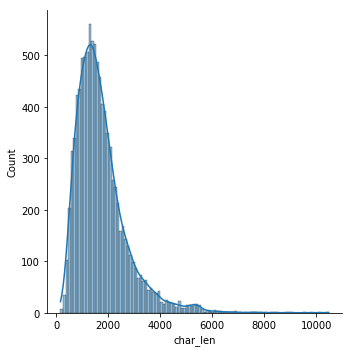

In [58]:
# Shows both bins and a smooth distribution line
sns.displot(df_CT[column_name], kde=True)

An ECDF(Empirical Cumulative Distribution Function) plot shows the exact cumulative percentage on the y-axis, making it simple to map any probability threshold directly to the actual value on the x-axis

In [59]:
def ECDF_plot(df):
    
    # Example Series
    #data = df['Inclusion_criteria_length'].dropna()--->new_data
    data = df[column_name].dropna()#---->old data(iter2)
    
    # Calculate percentile/outlier margins
    p1, p99 = data.quantile(0.01), data.quantile(0.99)
    p5, p95 = data.quantile(0.05), data.quantile(0.95)
    p10,p90 = data.quantile(0.10), data.quantile(0.90)
    p15,p85 = data.quantile(0.15), data.quantile(0.85)
    p20,p80 = data.quantile(0.20), data.quantile(0.80)

    print(f'80% range: [{p20:.2f}, {p80:.2f}]')
    print(f'85% range: [{p15:.2f}, {p85:.2f}]')
    print(f'90% range: [{p10:.2f}, {p90:.2f}]')
    print(f'95% range: [{p5:.2f}, {p95:.2f}]')
    print(f'99% range: [{p1:.2f}, {p99:.2f}]')

    plt.figure(figsize=(10, 5))
    sns.ecdfplot(data, color='blue', lw=2)

    # Mark 85% (0.85) level
    plt.axhline(0.85, color='brown', linestyle='--')
    plt.axvline(p85, color='brown', linestyle='--', label=f'85% at {p85:.2f}')

    # Mark 90% (0.90) level
    plt.axhline(0.90, color='green', linestyle='--')
    plt.axvline(p90, color='green', linestyle='--', label=f'90% at {p90:.2f}')

    # Mark 95% (0.95) level
    plt.axhline(0.95, color='orange', linestyle='--')
    plt.axvline(p95, color='orange', linestyle='--', label=f'95% at {p95:.2f}')

    # Mark 99% (0.99) level
    plt.axhline(0.99, color='red', linestyle='--')
    plt.axvline(p99, color='red', linestyle='--', label=f'99% at {p99:.2f}')

    plt.legend()
    plt.title('ECDF with Outlier Percentile Margins')
    plt.show()

80% range: [976.00, 2314.80]
85% range: [865.00, 2571.00]
90% range: [751.60, 2930.40]
95% range: [604.00, 3632.10]
99% range: [430.06, 5384.04]


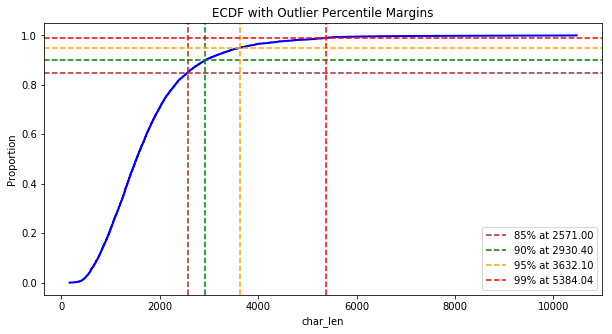

In [60]:
ECDF_plot(df_CT)#ECDF plot on df_CT to find outliers at different percentile levels(for both new and old--> use "Positive_chunk feild in case of old")

In [61]:
df_CT[column_name].median()

1531.0

In [66]:
# Good for spotting outliers and quartiles
#sns.boxplot(x=df_CT['Inclusion_criteria_length'])

In [67]:
# Combines a box plot with a density estimation
#sns.violinplot(x=df_CT['Inclusion_criteria_length'])

In [62]:
df_CT_under90quantile = df_CT[df_CT[column_name] <=2940]

In [63]:
df_CT_under90quantile.shape

(8835, 3)

#### ***(E1) We need to dwonsample our data to 2k(because LLM later would generate mutilple anchor questions son an average on each nctid)-<u>common for both old and new data</u>***

In [64]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import MiniBatchKMeans

In [65]:
def sample_cluster(group, target_per_cluster):
    if len(group) >= target_per_cluster:
        return group.head(target_per_cluster) # Prioritizes longer, text-dense records
    return group # Keep all if cluster is smaller than {target_per_cluster}

def versatile_2000(df, column_name, num_clusters, target_per_cluster, target_total):
    # Keep records with sufficient text density, sorting by length
    df = df.sort_values(by= column_name, ascending=False).reset_index(drop=True)
    
    # 3. Vectorize text with a fast TF-IDF array (Runs instantly on CPU)
    print("Vectorizing text patterns for diversity grouping...")
    tfidf = TfidfVectorizer(max_features=3000, stop_words="english", ngram_range=(1, 2))
    tfidf_matrix = tfidf.fit_transform(df[column_name])
    
    # 4. Use MiniBatchKMeans for rapid, memory-efficient clustering on 10k(9973~9972) rows
    print(f"Grouping trials into {num_clusters} semantic clinical clusters...")
    num_clusters = num_clusters
    kmeans = MiniBatchKMeans(n_clusters=num_clusters, random_state=42, batch_size=1000)
    df["cluster_id"] = kmeans.fit_predict(tfidf_matrix)
    print(f"shape of original_df adter adding cluster_id:-{df.shape}")
    
    # 5. Stratified Selection: Take exactly {target_per_cluster} high-quality records from each of the {num_clusters} clusters
    # This ensures rare conditions and unique trials are safely kept while overrepresented ones are trimmed.
    target_per_cluster = target_per_cluster

    df_diverse_2k = df.groupby("cluster_id", group_keys=False).apply(sample_cluster, target_per_cluster)
    print(df_diverse_2k.shape)
    # 3. Dynamic Padding Layer (Automatically captures the missing 20+ records)
    if len(df_diverse_2k) < target_total:
        needed = target_total - len(df_diverse_2k)
        # Gather all records that weren't selected in the first pass
        remaining_pool = df[~df["nctId"].isin(df_diverse_2k["nctId"])]
        # Randomly sample the exact remainder to hit 2,000
        padding_records = remaining_pool.sample(n=needed, random_state=42)
        df_final = pd.concat([df_diverse_2k, padding_records])
    else:
        df_final = df_diverse_2k.sample(n=target_total, random_state=42)
        
    return(df_final)
    

In [95]:
'''
# 2. Filter out short chunks to ensure the LLM has enough context to write smart questions
df_CT["char_len"] = df_CT["Positive_chunks"].str.len()
# Keep records with sufficient text density, sorting by length
df_CT = df_CT.sort_values(by="char_len", ascending=False).reset_index(drop=True)

# 3. Vectorize text with a fast TF-IDF array (Runs instantly on CPU)
print("Vectorizing text patterns for diversity grouping...")
tfidf = TfidfVectorizer(max_features=3000, stop_words="english", ngram_range=(1, 2))
tfidf_matrix = tfidf.fit_transform(df_CT["Positive_chunks"])

#tfidf_matrix[0]

# 4. Use MiniBatchKMeans for rapid, memory-efficient clustering on 10k(9973~9972) rows
print("Grouping trials into 36 semantic clinical clusters...")
num_clusters = 36
kmeans = MiniBatchKMeans(n_clusters=num_clusters, random_state=42, batch_size=1000)
df_CT["cluster_id"] = kmeans.fit_predict(tfidf_matrix)

# 5. Stratified Selection: Take exactly 40 high-quality records from each of the 50 clusters
# This ensures rare conditions and unique trials are safely kept while overrepresented ones are trimmed.
target_per_cluster = 55

def sample_cluster(group):
    if len(group) >= target_per_cluster:
        return group.head(target_per_cluster) # Prioritizes longer, text-dense records
    return group # Keep all if cluster is smaller than 40

df_CT_diverse_2k = df_CT.groupby("cluster_id", group_keys=False).apply(sample_cluster)
df_CT_diverse_2k.shape

target_total=2000
# 3. Dynamic Padding Layer (Automatically captures the missing 20+ records)
if len(df_CT_diverse_2k) < target_total:
    needed = target_total - len(df_CT_diverse_2k)
    # Gather all records that weren't selected in the first pass
    remaining_pool = df_CT[~df_CT["nctId"].isin(df_CT_diverse_2k["nctId"])]
    # Randomly sample the exact remainder to hit 2,000
    padding_records = remaining_pool.sample(n=needed, random_state=42)
    df_final = pd.concat([df_CT_diverse_2k, padding_records])
else:
    df_final = df_CT_diverse_2k.sample(n=target_total, random_state=42)
    
'''


'\n# 2. Filter out short chunks to ensure the LLM has enough context to write smart questions\ndf_CT["char_len"] = df_CT["Positive_chunks"].str.len()\n# Keep records with sufficient text density, sorting by length\ndf_CT = df_CT.sort_values(by="char_len", ascending=False).reset_index(drop=True)\n\n# 3. Vectorize text with a fast TF-IDF array (Runs instantly on CPU)\nprint("Vectorizing text patterns for diversity grouping...")\ntfidf = TfidfVectorizer(max_features=3000, stop_words="english", ngram_range=(1, 2))\ntfidf_matrix = tfidf.fit_transform(df_CT["Positive_chunks"])\n\n#tfidf_matrix[0]\n\n# 4. Use MiniBatchKMeans for rapid, memory-efficient clustering on 10k(9973~9972) rows\nprint("Grouping trials into 36 semantic clinical clusters...")\nnum_clusters = 36\nkmeans = MiniBatchKMeans(n_clusters=num_clusters, random_state=42, batch_size=1000)\ndf_CT["cluster_id"] = kmeans.fit_predict(tfidf_matrix)\n\n# 5. Stratified Selection: Take exactly 40 high-quality records from each of the 50 c

In [67]:
#df_final_top20k = versatile_2000(df_CT_under90quantile, column_name="TITLE", num_clusters=46, target_per_cluster=43, target_total=2000)
#------>for new data type
df_final_top20k = versatile_2000(df_CT_under90quantile, column_name="Positive_chunks", num_clusters=57, target_per_cluster=35, target_total=2000)
#-----> for old data type

Vectorizing text patterns for diversity grouping...
Grouping trials into 57 semantic clinical clusters...
shape of original_df adter adding cluster_id:-(8835, 4)
(1987, 4)


In [68]:
df_final_top20k =df_final_top20k.reset_index(drop=True)

In [69]:
df_final_top20k.shape

(2000, 4)

In [70]:
df_final_top20k.head()

,nctId,Positive_chunks,char_len,cluster_id
0,NCT07631078,TITLE: kTMP-Enhanced Motor Rehabilitation for ...,750,0
1,NCT07640360,TITLE: WATCH-STEP : Pilot Trial: Smartwatch-Gu...,1730,0
2,NCT07635498,TITLE: Virtual Stroke Units Versus Conventiona...,2105,0
3,NCT07690982,TITLE: Validity and Reliability of the PhysioM...,1839,0
4,NCT07702968,TITLE: Validation of Low Field MRI in Patients...,1296,0


80% range: [936.00, 2092.20]
85% range: [842.00, 2235.45]
90% range: [718.90, 2391.10]
95% range: [596.00, 2616.15]
99% range: [444.99, 2864.03]


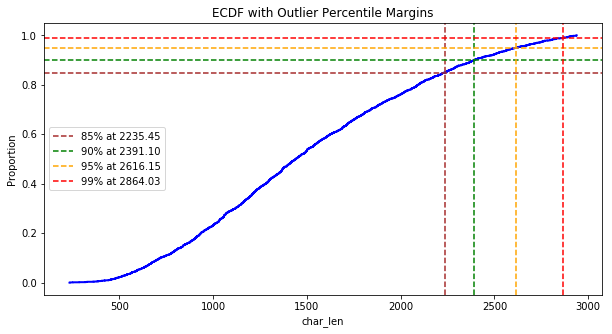

In [71]:
ECDF_plot(df_final_top20k)#ECDF plot on "df_final_top20k" to find outliers at different percentile levels

***<u>At this point old data(iter 1) was saved via df_final.to_parquet("CT_id_+veChunks.parquet"). Now following blocks are exclusive to new data(iter:-2)</u>***

In [73]:
df_final_top20k.to_parquet("CT_id_+veCleanedChunks.parquet")

#### (E2) with iterrows(), use df[field_name] for element access; with itertuples use df.field_name for element access-->exclusive for new data(iter-2)

In [119]:
def granulate(row):
    #title chunk
    d_title={}
    d_title["nctId"] =row.nctId
    d_title["chunk"] =row.TITLE
    d_title["chunk_length"] = len(row.TITLE)
    d_title["type"] ="title"
    d_title["block_no"] = 1

    #summary
    d_summary ={}
    d_summary["nctId"] =row.nctId
    d_summary["chunk"] =row.SUMMARY
    d_summary["chunk_length"] =len(row.SUMMARY)
    d_summary["type"] = "summary"
    d_summary["block_no"] = 2
    
    #INCLUSION_CRITERIa
    d_inclusion_criteria ={}
    d_inclusion_criteria["nctId"] =row.nctId
    d_inclusion_criteria["chunk"] = row.INCLUSION_CRITERIA
    d_inclusion_criteria["chunk_length"] =row.Inclusion_criteria_length
    d_inclusion_criteria["type"] = "inclusion_criteria"
    d_inclusion_criteria["block_no"] = 3
    
    nctId_ls=[]
    nctId_ls.append(d_title)
    nctId_ls.append(d_summary)
    nctId_ls.append(d_inclusion_criteria)
    
    return(pd.DataFrame(nctId_ls) )
    
    
    

In [129]:
# Using ThreadPoolExecutor to process rows concurrently
with ThreadPoolExecutor(max_workers=4) as executor:
    results = list(executor.map(granulate, df_final_top20k.itertuples()))
    total_len = len(list(executor.map(granulate, df_final_top20k.itertuples())))
    
    df_final_granule = pd.concat(list(tqdm(results, total =total_len, desc="Fetching_data")))
    df_final_granule =df_final_granule.reset_index(drop=True)

Fetching_data: 100%|███████████████████████████████████████████████████████████████████████| 2000/2000 [00:00<?, ?it/s]


In [130]:
df_final_granule.head()

,nctId,chunk,chunk_length,type,block_no
0,NCT07661732,eHealth Lifestyle Intervention To Enhance Outc...,198,title,1
1,NCT07661732,The goal of this clinical trial is to learn if...,1202,summary,2
2,NCT07661732,* Age over 18 years\n* Body mass index (BMI) o...,501,inclusion_criteria,3
3,NCT07704034,Wearable-Triggered Digital Safety Net for Real...,108,title,1
4,NCT07704034,This research study is for participants diagno...,515,summary,2


In [131]:
print(f"shape for final granulated data:-{df_final_granule.shape}, number of unique 'nctIds':-{df_final_granule['nctId'].nunique()}")

shape for final granulated data:-(6000, 5), number of unique 'nctIds':-2000


In [132]:
df_final_granule.to_parquet("CT_id_+veGranulatedChunks.parquet")

In [ ]:
!pip3 install pyarrow

### Convert file to pandas

In [ ]:
#df_chunk =pd.read_parquet("CT_id_+veChunks.parquet")

In [ ]:
#df_chunk.to_excel("CT_id_+veChunks.xlsx", engine="openpyxl")

In [ ]:
#df_CT_json =pd.read_json("ctg-studies.json")

In [ ]:
#df_CT_json.head()